In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"D:\College_work\ML\LAB_3\OnlineRetail.csv")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 08:26,3.39,17850.0,United Kingdom


In [4]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.shape

(541909, 8)

In [7]:
print(f"{df["Country"], df["InvoiceDate"]}")

(0         United Kingdom
1         United Kingdom
2         United Kingdom
3         United Kingdom
4         United Kingdom
               ...      
541904            France
541905            France
541906            France
541907            France
541908            France
Name: Country, Length: 541909, dtype: object, 0         12/1/2010 08:26
1         12/1/2010 08:26
2         12/1/2010 08:26
3         12/1/2010 08:26
4         12/1/2010 08:26
               ...       
541904    12/9/2011 12:50
541905    12/9/2011 12:50
541906    12/9/2011 12:50
541907    12/9/2011 12:50
541908    12/9/2011 12:50
Name: InvoiceDate, Length: 541909, dtype: object)


### Q1. Find mean, std dev, min , max of unitprice field.

In [8]:
mean_price = df["UnitPrice"].mean()
min_price = df["UnitPrice"].min()
max_price = df["UnitPrice"].max()
std_price = df["UnitPrice"].std()

print(f"Mean UnitPrice: {mean_price}")
print(f"Min UnitPrice: {min_price}")
print(f"Max UnitPrice: {max_price}")
print(f"Std dev UnitPrice: {std_price}")

Mean UnitPrice: 4.611113626088513
Min UnitPrice: -11062.06
Max UnitPrice: 38970.0
Std dev UnitPrice: 96.75985306119716


### Q2. Draw histogram of unitprice field using matplotlib

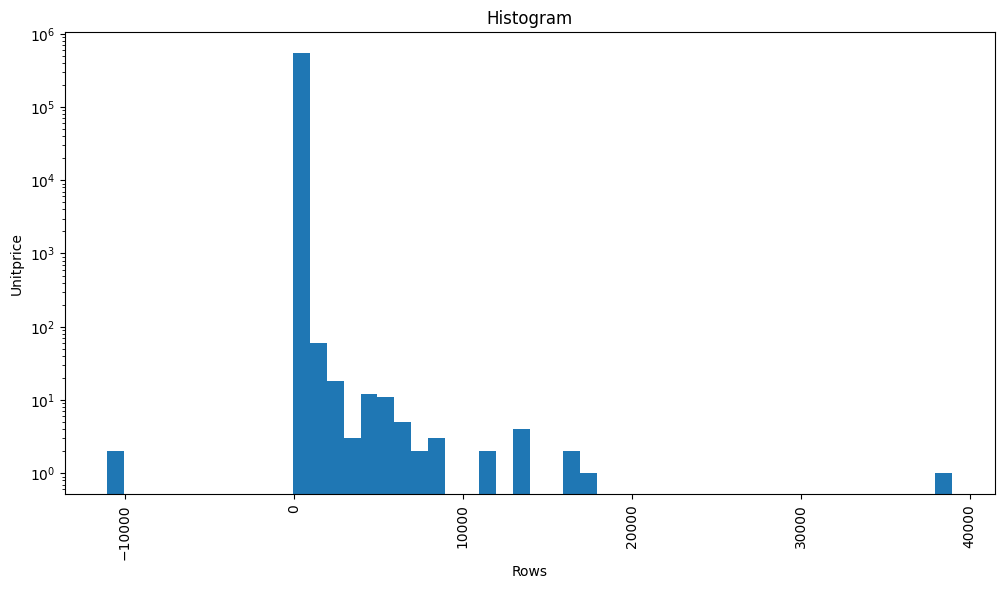

In [9]:
plt.figure(figsize=(12,6))
plt.hist(df["UnitPrice"], bins=50)

plt.title("Histogram")
plt.ylabel("Unitprice")
plt.xlabel("Rows")
plt.xticks(rotation = 90)
plt.yscale("log")
plt.show()

### Q3. Find mean of unitprice group by country and plot them

In [48]:
country_up = df.groupby("Country")["UnitPrice"].mean()
print(country_up)

Country
Australia                 3.220612
Austria                   4.243192
Bahrain                   4.556316
Belgium                   3.644335
Brazil                    4.456250
Canada                    6.030331
Channel Islands           4.932124
Cyprus                    6.302363
Czech Republic            2.938333
Denmark                   3.256941
EIRE                      5.911077
European Community        4.820492
Finland                   5.448705
France                    5.028864
Germany                   3.966930
Greece                    4.885548
Hong Kong                42.505208
Iceland                   2.644011
Israel                    3.633131
Italy                     4.831121
Japan                     2.276145
Lebanon                   5.387556
Lithuania                 2.841143
Malta                     5.244173
Netherlands               2.738317
Norway                    6.012026
Poland                    4.170880
Portugal                  8.582976
RSA         

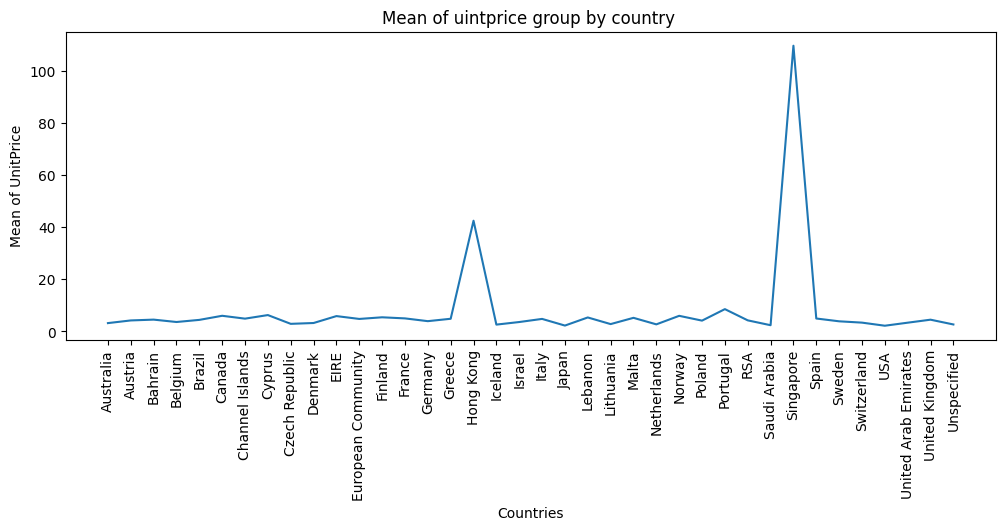

In [50]:
plt.figure(figsize=(12,4))
plt.plot(country_up )
plt.title("Mean of uintprice group by country ")
plt.xlabel("Countries")
plt.xticks(rotation = 90)
plt.ylabel("Mean of UnitPrice")
# plt.yscale("log")
plt.show()

### Q4. Find min and max of unit price group by customerID

In [11]:
df.groupby('CustomerID')['UnitPrice'].agg(['min','max'])

,min,max
CustomerID,,
12346.0,1.04,1.04
12347.0,0.25,12.75
12348.0,0.29,40.00
12349.0,0.42,300.00
12350.0,0.85,40.00
...,...,...
18280.0,2.55,9.95
18281.0,0.42,16.95
18282.0,0.29,12.75


### Q5. Find cumulative sales monthly and yearly and plot them using both Matplotlib and Sea Borne.


In [19]:
df['sales'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df["InvoiceDate"])

monthly_sales = df.resample('M', on='InvoiceDate')['sales'].sum()
monthly_cumulative = monthly_sales.cumsum()

yearly_sales = df.groupby(df['InvoiceDate'].dt.year)["sales"].sum()
yearly_cumulative = yearly_sales.cumsum()

C:\Users\Asus\AppData\Local\Temp\ipykernel_12620\707790551.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='InvoiceDate')['sales'].sum()


Matplotlib (Monthly)

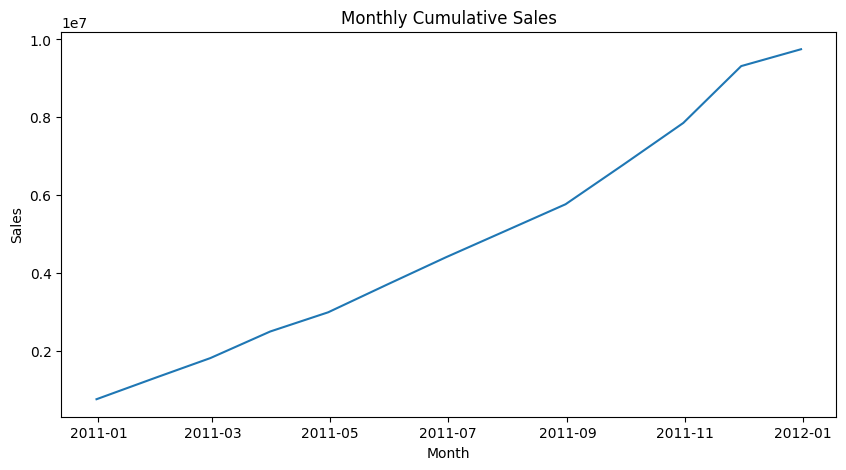

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(monthly_cumulative)
plt.title("Monthly Cumulative Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

Seaborn (Monthly)

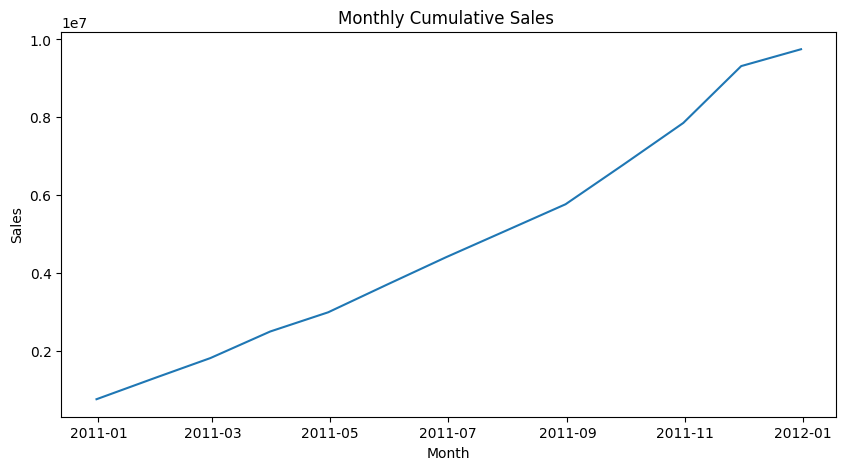

In [21]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_cumulative.index, y= monthly_cumulative.values)

plt.title("Monthly Cumulative Sales ")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

Matplotlib (Yearly)

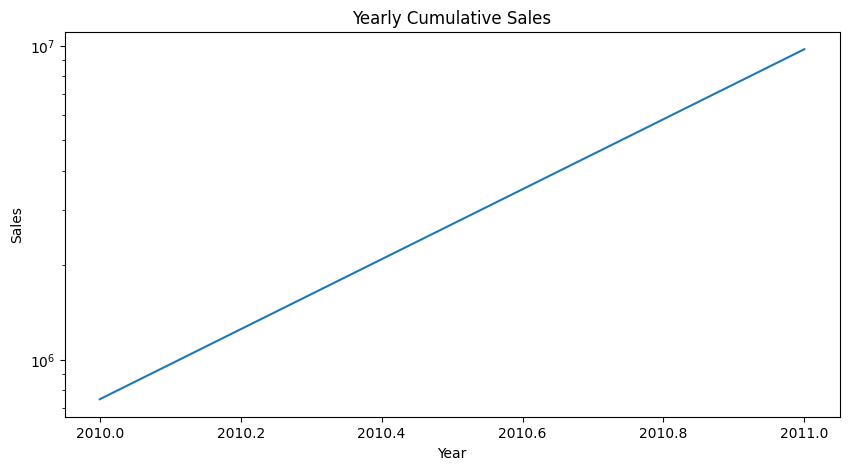

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(yearly_cumulative)
plt.title("Yearly Cumulative Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.yscale("log")
plt.show()

Seaborn (Yearly)

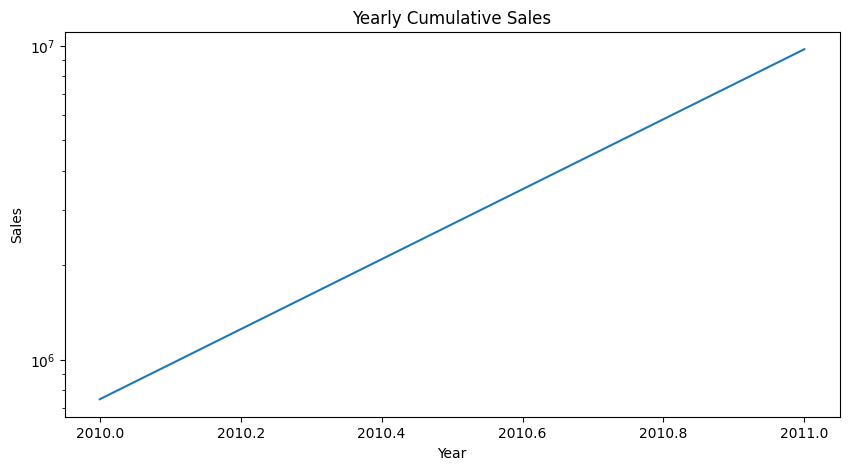

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(yearly_cumulative.index, yearly_cumulative.values)

plt.title("Yearly Cumulative Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.yscale("log")

plt.show()